# Budget Phasing Walkthrough

Notebook 01 showed the problem: when TV, Meta, and Search spend are all correlated, OLS elasticity estimates are unreliable. The same market gives wildly different answers depending on which period of data you happened to use.

This notebook shows the fix. `BudgetPhaser` takes your historical spend (multiple years) and your upcoming plan year, then finds the optimal amount of independent weekly variation to introduce into the plan-year channel mix — while keeping monthly budgets intact.

**Why does history matter?** An MMM is fit on 3–5 years of data, not just the plan year. Even if the plan year is beautifully de-correlated, four years of correlated history will dilute the benefit. `BudgetPhaser` accounts for this by evaluating each candidate phasing against the *full* dataset (history + phased plan), not the plan year in isolation.

The output is a concrete week-by-week schedule you can hand to your media agency.

In [1]:
FAST_MODE = False  # set False for publication-quality runs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong_is_your_mmm import (
    Blackout,
    BudgetPhaser,
    CollinearityDiagnostic,
    simulate_spend,
)
from how_wrong_is_your_mmm._phaser import (
    _generate_phased_schedule,
    _get_month_labels,
)

## The data

We simulate four years of weekly historical spend (208 weeks) plus one year of plan spend (52 weeks), all with high inter-channel correlation — the realistic scenario where an MMM struggles.

The `start_date` gives both DataFrames a proper `DatetimeIndex`, required by `BudgetPhaser` so it knows which weeks belong to which month.

In [3]:
history = simulate_spend(n_obs=208, correlation=0.7, seed=0, start_date="2019-01-07")
plan = simulate_spend(n_obs=52, correlation=0.7, seed=1, start_date="2023-01-09")

print(
    f"History: {history.shape[0]} weeks  ({history.index[0].date()} to {history.index[-1].date()})"
)
print(
    f"Plan:    {plan.shape[0]} weeks  ({plan.index[0].date()} to {plan.index[-1].date()})"
)
print()
print("Plan channel spend:")
for ch in plan.columns:
    print(
        f"  {ch.upper():6s}  mean weekly: £{plan[ch].mean():,.0f}  annual: £{plan[ch].sum():,.0f}"
    )
print()
print("Correlation matrix (plan year):")
print(plan.corr().round(2))

History: 208 weeks  (2019-01-07 to 2022-12-26)
Plan:    52 weeks  (2023-01-09 to 2024-01-01)

Plan channel spend:
  TV      mean weekly: £98,031  annual: £5,097,606
  META    mean weekly: £78,190  annual: £4,065,889
  SEARCH  mean weekly: £59,621  annual: £3,100,269

Correlation matrix (plan year):
          tv  meta  search
tv      1.00  0.68    0.68
meta    0.68  1.00    0.67
search  0.68  0.67    1.00


## Baseline unreliability

Before recommending any changes, we establish how unreliable the current situation is. We run `CollinearityDiagnostic` on the full 5-year dataset (history + unphased plan) to show what the MMM would produce today.

In [4]:
n_sims = 10 if FAST_MODE else 50

combined_baseline = pd.concat([history, plan])
baseline = CollinearityDiagnostic(
    spend_df=combined_baseline,
    true_elasticities={"tv": 0.3, "meta": 0.5, "search": 0.4},
)
baseline.fit(n_sims=n_sims, fast_mode=FAST_MODE)
print("Baseline (history + unphased plan):")
print(baseline.summary().to_string(index=False))

Baseline (history + unphased plan):
channel  true_elasticity  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta              0.5          0.4969         0.1175         -0.6216             0.2364
 search              0.4          0.4251         0.1486          6.2725             0.3497
     tv              0.3          0.2948         0.0948         -1.7338             0.3216


## Running BudgetPhaser

The phaser grid-searches over a phasing amplitude alpha in [0, 1]:

- **alpha = 0** — no change from original plan
- **alpha = 1** — maximum allowed weekly deviation (40% per channel by default)

For each alpha it generates a phased schedule — redistributing each channel's weekly spend within each month, monthly totals exactly preserved — then runs `CollinearityDiagnostic` on history + phased plan (plain OLS).

A research study (notebook 03, Section 3) compared weighting the plan year more heavily against the correlated history and found uniform weighting always won, so no weighting scheme is applied: every observation counts equally.


In [5]:
grid_steps = 10 if FAST_MODE else 25
n_phasing_seeds = 1 if FAST_MODE else 10

phaser = BudgetPhaser(
    history_df=history,
    plan_df=plan,
    true_elasticities={"tv": 0.3, "meta": 0.5, "search": 0.4},
    max_weekly_deviation_pct=40.0,
)
phaser.fit(
    n_sims=n_sims,
    grid_steps=grid_steps,
    n_phasing_seeds=n_phasing_seeds,
    fast_mode=FAST_MODE,
)

print(phaser.summary().to_string(index=False))

 alpha  actual_correlation  max_cv  max_monthly_deviation_pct  cv_tv  cv_meta  cv_search
0.0000              0.6942  0.3497                        0.0 0.3216   0.2364     0.3497
0.0417              0.6940  0.3486                        0.0 0.3214   0.2364     0.3486
0.0833              0.6938  0.3483                        0.0 0.3188   0.2358     0.3483
0.1250              0.6933  0.3509                        0.0 0.3188   0.2347     0.3509
0.1667              0.6904  0.3442                        0.0 0.3180   0.2347     0.3442
0.2083              0.6885  0.3491                        0.0 0.3176   0.2351     0.3491
0.2500              0.6880  0.3476                        0.0 0.3168   0.2342     0.3476
0.2917              0.6858  0.3398                        0.0 0.3193   0.2312     0.3398
0.3333              0.6796  0.3412                        0.0 0.3155   0.2274     0.3412
0.3750              0.6829  0.3420                        0.0 0.3052   0.2283     0.3420
0.4167              0

## The CV curve

The chart shows how elasticity reliability (max CV across channels) and inter-channel correlation change as phasing amplitude increases. The green dashed line marks the recommended alpha.

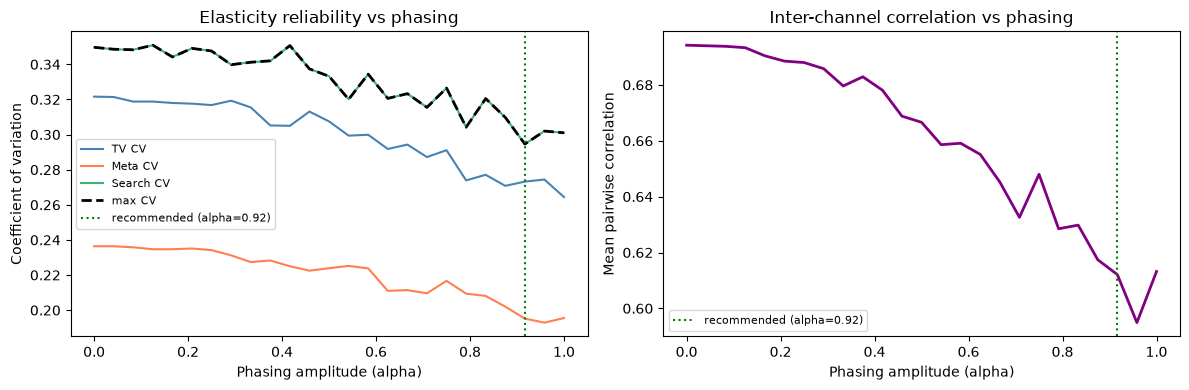

In [6]:
results = phaser.summary()
rec = phaser.recommend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(results["alpha"], results["cv_tv"], color="steelblue", label="TV CV")
ax.plot(results["alpha"], results["cv_meta"], color="coral", label="Meta CV")
ax.plot(
    results["alpha"], results["cv_search"], color="mediumseagreen", label="Search CV"
)
ax.plot(
    results["alpha"],
    results["max_cv"],
    color="black",
    linewidth=2,
    linestyle="--",
    label="max CV",
)
ax.axvline(
    rec["alpha"],
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"recommended (alpha={rec['alpha']:.2f})",
)
ax.set_xlabel("Phasing amplitude (alpha)")
ax.set_ylabel("Coefficient of variation")
ax.set_title("Elasticity reliability vs phasing")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(results["alpha"], results["actual_correlation"], color="purple", linewidth=2)
ax.axvline(
    rec["alpha"],
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"recommended (alpha={rec['alpha']:.2f})",
)
ax.set_xlabel("Phasing amplitude (alpha)")
ax.set_ylabel("Mean pairwise correlation")
ax.set_title("Inter-channel correlation vs phasing")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## How phasing affects elasticity estimates

CV is a useful metric, but this chart makes the improvement tangible. We run `CollinearityDiagnostic` at three phasing levels — no phasing (alpha=0), the recommended alpha, and maximum phasing (alpha=1) — using the same OLS evaluation as the phaser. The distribution of estimated elasticities across simulation seeds is plotted against the true value.

Narrower spread = more reliable model.

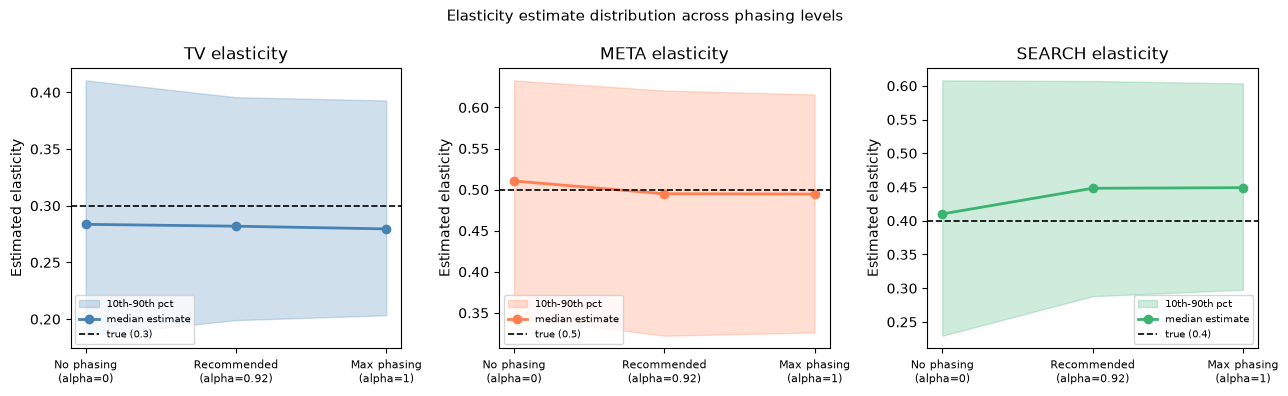

In [7]:
month_labels = _get_month_labels(plan)
true_elasticities = {"tv": 0.3, "meta": 0.5, "search": 0.4}
best_alpha = phaser.recommend()["alpha"]

alpha_levels = {
    f"No phasing\n(alpha=0)": 0.0,
    f"Recommended\n(alpha={best_alpha:.2f})": best_alpha,
    f"Max phasing\n(alpha=1)": 1.0,
}

elast_data = {}
for label, alpha in alpha_levels.items():
    phased = _generate_phased_schedule(
        plan,
        month_labels,
        alpha=alpha,
        max_weekly_deviation_pct=phaser.max_weekly_deviation_pct,
        seed=99,
    )
    combined = pd.concat([history, phased])
    diag = CollinearityDiagnostic(
        spend_df=combined,
        true_elasticities=true_elasticities,
    )
    diag.fit(n_sims=n_sims)
    elast_data[label] = {
        ch: diag.results_[diag.results_["channel"] == ch][
            "estimated_elasticity"
        ].to_numpy()
        for ch in plan.columns
    }

channel_colors = {"tv": "steelblue", "meta": "coral", "search": "mediumseagreen"}
labels = list(alpha_levels.keys())
x = range(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, ch in zip(axes, plan.columns):
    color = channel_colors[ch]
    true_val = true_elasticities[ch]
    medians = [float(np.median(elast_data[l][ch])) for l in labels]
    p10s = [float(np.percentile(elast_data[l][ch], 10)) for l in labels]
    p90s = [float(np.percentile(elast_data[l][ch], 90)) for l in labels]

    ax.fill_between(x, p10s, p90s, alpha=0.25, color=color, label="10th-90th pct")
    ax.plot(x, medians, color=color, linewidth=2, marker="o", label="median estimate")
    ax.axhline(
        true_val,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"true ({true_val})",
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"{ch.upper()} elasticity")
    ax.set_ylabel("Estimated elasticity")
    ax.legend(fontsize=7)

plt.suptitle("Elasticity estimate distribution across phasing levels", fontsize=11)
plt.tight_layout()
plt.show()

## The recommendation

In [8]:
rec = phaser.recommend()
baseline_row = phaser.summary().iloc[0]
cv_reduction = 100 * (baseline_row["max_cv"] - rec["max_cv"]) / baseline_row["max_cv"]
max_dev_pct = phaser.max_weekly_deviation_pct * rec["alpha"]

print("Recommendation")
print("=" * 60)
print(f"Phasing amplitude:             alpha = {rec['alpha']:.2f}")
print(
    f"Max weekly deviation:          +/-{max_dev_pct:.0f}% of original weekly spend per channel"
)
print()
print(f"Correlation (combined, alpha=0):  {baseline_row['actual_correlation']:.2f}")
print(f"Correlation (combined, recommended): {rec['actual_correlation']:.2f}")
print()
print(f"Max CV (alpha=0):              {baseline_row['max_cv']:.3f}")
print(f"Max CV (recommended):          {rec['max_cv']:.3f}")
print(f"CV reduction:                  {cv_reduction:.0f}%")

Recommendation
Phasing amplitude:             alpha = 0.92
Max weekly deviation:          +/-37% of original weekly spend per channel

Correlation (combined, alpha=0):  0.69
Correlation (combined, recommended): 0.61

Max CV (alpha=0):              0.350
Max CV (recommended):          0.295
CV reduction:                  16%


## CAC and ROI, before and after phasing

CV is the right metric for tuning `BudgetPhaser` (the grid search minimises max CV, not any £ number), but a CAC or ROI range is what a CMO understands. Reusing the same three phasing levels from the elasticity chart above, `value_per_unit` (an illustrative £150 average LTV per acquisition, same as notebook 01) converts each into `cac = 1 / elasticity` and `roi = elasticity * value_per_unit`.

One honesty note carried over from notebook 01: only the *worst-case* channel is guaranteed to improve — that's the metric `BudgetPhaser` actually optimises for (see "The recommendation" above). Other channels can move in either direction between phasing levels, same as their raw elasticity ranges can. The number below is reported for the worst-case channel specifically, for that reason.


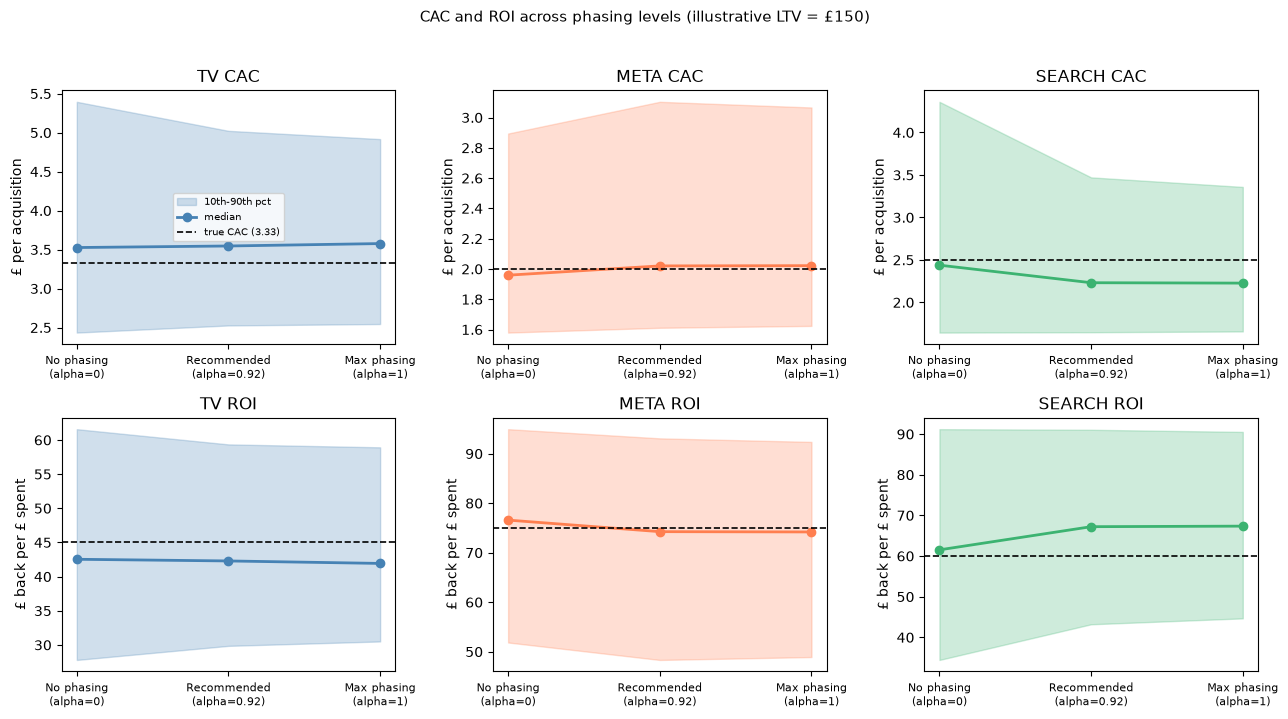

In [9]:
value_per_unit = 150.0  # illustrative avg LTV per acquisition, same as notebook 01

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=False)

for col, ch in enumerate(plan.columns):
    color = channel_colors[ch]
    true_val_e = true_elasticities[ch]

    ax = axes[0, col]
    cac_by_label = {l: 1 / elast_data[l][ch] for l in labels}
    medians = [float(np.median(cac_by_label[l])) for l in labels]
    p10s = [float(np.percentile(cac_by_label[l], 10)) for l in labels]
    p90s = [float(np.percentile(cac_by_label[l], 90)) for l in labels]
    ax.fill_between(x, p10s, p90s, alpha=0.25, color=color, label="10th-90th pct")
    ax.plot(x, medians, color=color, linewidth=2, marker="o", label="median")
    ax.axhline(
        1 / true_val_e,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"true CAC ({1 / true_val_e:.2f})",
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"{ch.upper()} CAC")
    ax.set_ylabel("\u00a3 per acquisition")
    if col == 0:
        ax.legend(fontsize=7)

    ax = axes[1, col]
    roi_by_label = {l: elast_data[l][ch] * value_per_unit for l in labels}
    medians = [float(np.median(roi_by_label[l])) for l in labels]
    p10s = [float(np.percentile(roi_by_label[l], 10)) for l in labels]
    p90s = [float(np.percentile(roi_by_label[l], 90)) for l in labels]
    ax.fill_between(x, p10s, p90s, alpha=0.25, color=color)
    ax.plot(x, medians, color=color, linewidth=2, marker="o")
    ax.axhline(
        true_val_e * value_per_unit, color="black", linestyle="--", linewidth=1.2
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"{ch.upper()} ROI")
    ax.set_ylabel("\u00a3 back per \u00a3 spent")

plt.suptitle(
    f"CAC and ROI across phasing levels (illustrative LTV = \u00a3{value_per_unit:.0f})",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [10]:
# Worst-case channel is the one BudgetPhaser actually optimises for (max CV).
baseline_row = results.iloc[0]
worst_channel = max(plan.columns, key=lambda ch: baseline_row[f"cv_{ch}"])
print(f"Worst-case channel at baseline: {worst_channel.upper()}")
print()

for metric_name, transform, unit in [
    ("CAC", lambda d: 1 / d, "\u00a3 per acquisition"),
    ("ROI", lambda d: d * value_per_unit, "\u00a3 back per \u00a3 spent"),
]:
    base_draws = transform(elast_data[labels[0]][worst_channel])
    rec_draws = transform(elast_data[labels[1]][worst_channel])
    w_base = np.percentile(base_draws, 90) - np.percentile(base_draws, 10)
    w_rec = np.percentile(rec_draws, 90) - np.percentile(rec_draws, 10)
    change_pct = 100 * (w_base - w_rec) / w_base
    print(
        f"{metric_name} range width ({worst_channel.upper()}, {unit}): "
        f"{w_base:.2f} -> {w_rec:.2f}  ({change_pct:+.0f}%)"
    )

Worst-case channel at baseline: SEARCH

CAC range width (SEARCH, £ per acquisition): 2.72 -> 1.82  (+33%)
ROI range width (SEARCH, £ back per £ spent): 56.77 -> 47.85  (+16%)


Narrower CAC and ROI bands are the same underlying improvement as narrower CV, just expressed in the currency a budget conversation actually runs on.


## The recommended schedule

The recommended schedule is a concrete 52-week spend plan for the plan year. Monthly totals are preserved exactly — the only change is how the budget is paced week-to-week within each month.

In [11]:
sched = phaser.recommended_schedule_

orig_monthly = plan.resample("ME").sum().round(0)
new_monthly = sched.resample("ME").sum().round(0)

print("Monthly totals — original plan vs recommended (GBP):")
print()
for ch in plan.columns:
    print(f"{ch.upper()}")
    comparison = pd.DataFrame(
        {"original": orig_monthly[ch], "recommended": new_monthly[ch]}
    )
    comparison["difference"] = comparison["recommended"] - comparison["original"]
    print(comparison.to_string())
    print()

Monthly totals — original plan vs recommended (GBP):

TV
            original  recommended  difference
2023-01-31  404382.0     404382.0         0.0
2023-02-28  419169.0     419169.0         0.0
2023-03-31  401598.0     401598.0         0.0
2023-04-30  393877.0     393877.0         0.0
2023-05-31  457592.0     457592.0         0.0
2023-06-30  406658.0     406658.0         0.0
2023-07-31  444907.0     444907.0         0.0
2023-08-31  436890.0     436890.0         0.0
2023-09-30  386524.0     386524.0         0.0
2023-10-31  489900.0     489900.0         0.0
2023-11-30  332245.0     332245.0         0.0
2023-12-31  431467.0     431467.0         0.0
2024-01-31   92397.0      92397.0         0.0

META
            original  recommended  difference
2023-01-31  315177.0     315177.0         0.0
2023-02-28  351718.0     351718.0         0.0
2023-03-31  345464.0     345464.0         0.0
2023-04-30  302241.0     302241.0         0.0
2023-05-31  387597.0     387597.0         0.0
2023-06-30  28512

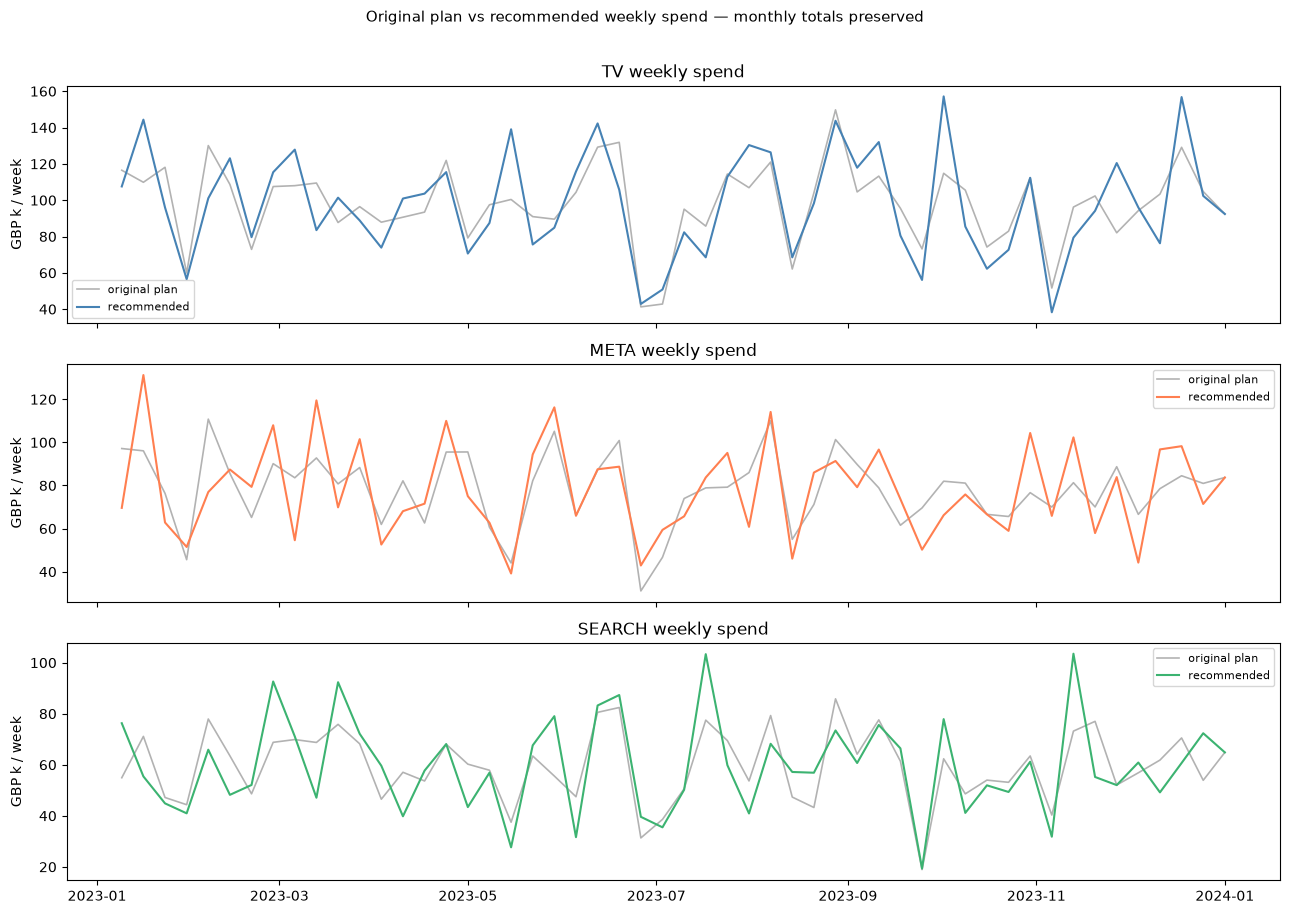

In [12]:
channels_cfg = [
    ("tv", "steelblue"),
    ("meta", "coral"),
    ("search", "mediumseagreen"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, (ch, color) in zip(axes, channels_cfg):
    ax.plot(
        plan.index,
        plan[ch] / 1000,
        color="grey",
        alpha=0.6,
        linewidth=1.2,
        label="original plan",
    )
    ax.plot(
        sched.index, sched[ch] / 1000, color=color, linewidth=1.5, label="recommended"
    )
    ax.set_ylabel("GBP k / week")
    ax.set_title(f"{ch.upper()} weekly spend")
    ax.legend(fontsize=8)

plt.suptitle(
    "Original plan vs recommended weekly spend — monthly totals preserved",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.show()

## What this achieves

The recommended schedule introduces independent variation in the weekly channel mix — some weeks TV gets a larger share of its monthly budget, others less — while Meta and Search follow their own independent patterns. Monthly commitments are unchanged.

The evaluation is honest: it accounts for four years of correlated history by evaluating each candidate phasing against history + phased plan together, not the plan year in isolation. The CV reduction shown above is what a practitioner can realistically expect from their MMM after adopting the phased schedule.


## Per-channel deviation constraints

In practice, a media agency rarely lets every channel move by the same amount. TV bookings might be locked well in advance and simply can't be reshuffled week to week. `BudgetPhaser` supports this: `max_weekly_deviation_pct` accepts a dict per channel, and each channel's value can be a single number (symmetric +/-) or a `Blackout()` instance for a hard on/off switch instead of a continuous range.

Below: TV is locked at 0% (can't move at all), Meta is free to move +/-60% either way, and Search uses `Blackout()`: each week is either at its full planned amount or exactly GBP 0, nothing in between.

### Blackout mode: a hard on/off switch

Sometimes the real answer from an agency is blunter than a continuous range: a channel is either spent at its full planned amount, or switched off entirely for the week. `Blackout()` models exactly that.

By default, each week is an independent draw, so a bad month can land several dark weeks at once, and the few weeks left "on" have to absorb the whole month's diverted budget, which can mean spending several times the original plan in a single week, more than a media buyer could realistically deploy. Setting `max_dark_weeks_per_month=1` caps this: at most one week per month goes dark, so at most one week's budget ever needs to be picked up by the rest of the month, keeping the resulting increase modest and plausible.

In [13]:
phaser_blackout = BudgetPhaser(
    history_df=history,
    plan_df=plan,
    true_elasticities={"tv": 0.3, "meta": 0.5, "search": 0.4},
    max_weekly_deviation_pct={
        "tv": 0.0,
        "meta": 60.0,
        "search": Blackout(max_dark_weeks_per_month=1),
    },
)
phaser_blackout.fit(
    n_sims=n_sims,
    grid_steps=grid_steps,
    n_phasing_seeds=n_phasing_seeds,
    fast_mode=FAST_MODE,
)

rec_blackout = phaser_blackout.recommend()
baseline_row_blackout = phaser_blackout.summary().iloc[0]
cv_reduction_blackout = (
    100
    * (baseline_row_blackout["max_cv"] - rec_blackout["max_cv"])
    / baseline_row_blackout["max_cv"]
)

print(
    "Recommendation, TV locked / Meta +/-60% / Search Blackout(max_dark_weeks_per_month=1)"
)
print("=" * 60)
print(f"Phasing amplitude:             alpha = {rec_blackout['alpha']:.2f}")
print(f"Max CV (alpha=0):              {baseline_row_blackout['max_cv']:.3f}")
print(f"Max CV (recommended):          {rec_blackout['max_cv']:.3f}")
print(f"CV reduction:                  {cv_reduction_blackout:.0f}%")

sched_blackout = phaser_blackout.recommended_schedule_
tv_unchanged = np.allclose(sched_blackout["tv"].to_numpy(), plan["tv"].to_numpy())
n_dark_weeks = (sched_blackout["search"] == 0.0).sum()
search_max = sched_blackout["search"].max()
print(f"\nTV schedule identical to original plan: {tv_unchanged}")
print(f"Search weeks at exactly GBP 0: {n_dark_weeks} of {len(plan)}")
print(
    f"Search max weekly spend: GBP {search_max:,.0f} "
    f"(original max: GBP {plan['search'].max():,.0f})"
)

Recommendation, TV locked / Meta +/-60% / Search Blackout(max_dark_weeks_per_month=1)
Phasing amplitude:             alpha = 0.92
Max CV (alpha=0):              0.350
Max CV (recommended):          0.290
CV reduction:                  17%

TV schedule identical to original plan: True
Search weeks at exactly GBP 0: 11 of 52
Search max weekly spend: GBP 122,199 (original max: GBP 85,838)


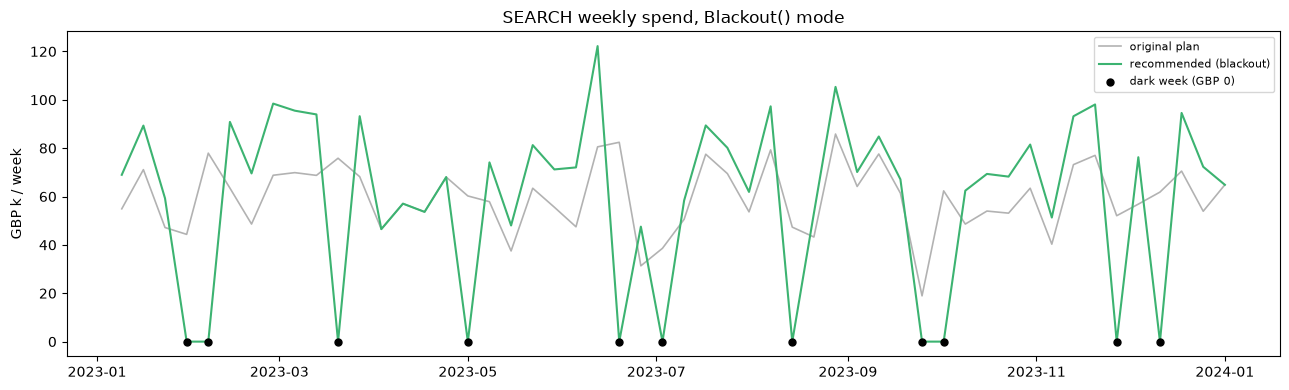

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    plan.index,
    plan["search"] / 1000,
    color="grey",
    alpha=0.6,
    linewidth=1.2,
    label="original plan",
)
ax.plot(
    sched_blackout.index,
    sched_blackout["search"] / 1000,
    color="mediumseagreen",
    linewidth=1.5,
    label="recommended (blackout)",
)

dark_mask = sched_blackout["search"] == 0.0
ax.scatter(
    sched_blackout.index[dark_mask],
    sched_blackout["search"][dark_mask] / 1000,
    color="black",
    zorder=5,
    s=25,
    label="dark week (GBP 0)",
)

ax.set_ylabel("GBP k / week")
ax.set_title("SEARCH weekly spend, Blackout() mode")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Every black dot is a week where Search spend is exactly GBP 0, not just small, the guarantee `Blackout()` makes that a continuous range can't. The weeks that stay on pick up the difference so the monthly total still lands exactly on plan, but with `max_dark_weeks_per_month=1` at most one week per month goes dark, so at most one week's budget needs a new home, keeping the increase on the surviving weeks modest rather than extreme.

This is the realistic case for most practitioners: you rarely get to move every channel freely, and even the channel that can be turned off needs a limit on how often, so the resulting ask is something a media buyer could actually execute.

### Locking TV vs letting Search go dark: three follow-up questions

Three natural follow-ups to the constraints above:

1. **What if TV can't be phased at all?** TV bookings are often locked in well in advance, so what does full phasing (TV included) actually buy over phasing only Meta and Search?
2. **Given TV and Meta still move normally, how much extra reliability comes from letting Search use `Blackout()` instead of a continuous range**, at the same nominal 40% deviation budget?
3. **Is Blackout the way to go generally — what if every channel used it?**

The table and chart below compare four scenarios, at the same history, plan, and grid-search settings used throughout this notebook: the baseline (all three channels on a symmetric +/-40% range), TV locked at 0% (Meta and Search still symmetric +/-40%), Search switched to `Blackout(max_dark_weeks_per_month=1)` while TV and Meta stay on their normal symmetric +/-40% range, and all three channels on `Blackout(max_dark_weeks_per_month=1)`.

In [15]:
comparison_scenarios = {
    "Baseline\n(all symmetric)": 40.0,
    "TV locked\n(Meta/Search only)": {"tv": 0.0, "meta": 40.0, "search": 40.0},
    "Search Blackout\n(TV/Meta normal)": {
        "tv": 40.0,
        "meta": 40.0,
        "search": Blackout(max_dark_weeks_per_month=1),
    },
    "All-Blackout\n(every channel)": Blackout(max_dark_weeks_per_month=1),
}

comparison_rows = []
for label, dev in comparison_scenarios.items():
    p = BudgetPhaser(
        history_df=history,
        plan_df=plan,
        true_elasticities=true_elasticities,
        max_weekly_deviation_pct=dev,
    )
    p.fit(
        n_sims=n_sims,
        grid_steps=grid_steps,
        n_phasing_seeds=n_phasing_seeds,
        fast_mode=FAST_MODE,
    )
    base_row = p.summary().iloc[0]
    rec_row = p.recommend()
    sched = p.recommended_schedule_
    comparison_rows.append(
        {
            "scenario": label.replace("\n", " "),
            "alpha": rec_row["alpha"],
            "max_cv_reduction_pct": 100
            * (base_row["max_cv"] - rec_row["max_cv"])
            / base_row["max_cv"],
            **{
                f"{ch}_reduction_pct": 100
                * (base_row[f"cv_{ch}"] - rec_row[f"cv_{ch}"])
                / base_row[f"cv_{ch}"]
                for ch in plan.columns
            },
            **{
                f"{ch}_max_spend_ratio": sched[ch].max() / plan[ch].max()
                for ch in plan.columns
            },
        }
    )

comparison_df = pd.DataFrame(comparison_rows).round(2)
print(comparison_df.to_string(index=False))

                        scenario  alpha  max_cv_reduction_pct  tv_reduction_pct  meta_reduction_pct  search_reduction_pct  tv_max_spend_ratio  meta_max_spend_ratio  search_max_spend_ratio
        Baseline (all symmetric)   0.92                 15.76             15.05               17.43                 15.76                1.05                  1.18                    1.21
    TV locked (Meta/Search only)   0.79                 11.61              3.89               11.00                 12.87                1.00                  1.14                    1.16
Search Blackout (TV/Meta normal)   0.79                 26.08             19.62               12.39                 37.20                1.11                  1.14                    1.45
    All-Blackout (every channel)   1.00                 46.81             48.63               52.12                 46.81                1.29                  1.26                    1.44


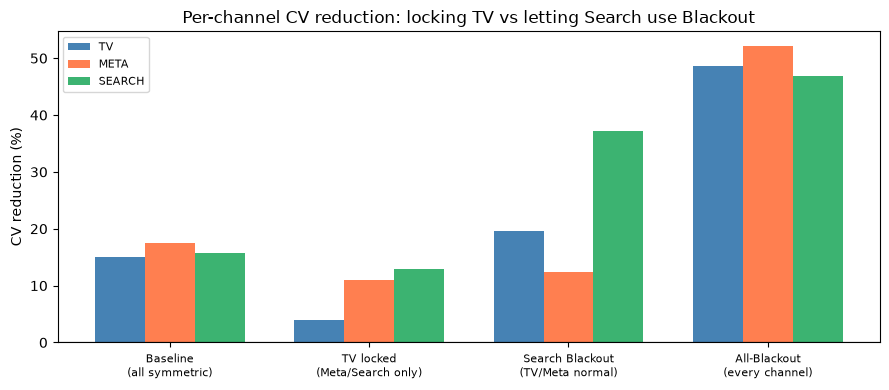

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
scenario_labels = list(comparison_scenarios.keys())
channels = list(plan.columns)
bar_width = 0.25
x = np.arange(len(scenario_labels))

for i, ch in enumerate(channels):
    ax.bar(
        x + i * bar_width,
        comparison_df[f"{ch}_reduction_pct"],
        width=bar_width,
        color=channel_colors[ch],
        label=ch.upper(),
    )

ax.set_xticks(x + bar_width)
ax.set_xticklabels(scenario_labels, fontsize=8)
ax.set_ylabel("CV reduction (%)")
ax.set_title("Per-channel CV reduction: locking TV vs letting Search use Blackout")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Locking TV costs more than it might look like.** TV's own CV barely moves when it's held fixed, its own week-to-week variation still tracks the same demand signal as before, while letting it move normally accounts for most of TV's own reliability gain. Meta and Search still improve somewhat even with TV locked, because their movement alone loosens *their* collinearity with the now-fixed TV, but the overall (max-CV) benefit is noticeably smaller than when every channel is free to move.

**Blackout buys more reliability per unit of disruption than a continuous range.** At the same nominal 40% deviation budget, switching Search from a symmetric range to `Blackout(max_dark_weeks_per_month=1)` produces a substantially bigger reduction in Search's own CV, plus a modest knock-on improvement for TV and Meta (phasing one channel harder loosens its collinearity with the others too). The trade-off is the one already discussed above: Blackout's variation is concentrated into a few weeks carrying the month's budget rather than spread continuously, so it's a stronger lever but a blunter one to hand to a media buyer.

**Is Blackout the way to go generally? Directionally, yes — checked across three independent data draws, not just the one used elsewhere in this notebook.** Switching *every* channel to `Blackout(max_dark_weeks_per_month=1)` beat both the symmetric baseline and the Search-only Blackout scenario every time (max-CV reduction roughly 47-59% for all-Blackout, versus 16-24% for the baseline and 17-49% for Search-only, across the three draws), while the practical cost stayed modest and consistent: about 12 of 52 weeks dark per channel (one per month, as designed) and a max weekly spend of roughly 1.2-1.4x the original plan, similar to the single-channel case, not worse. So all-Blackout isn't a fluke of one dataset, though it is still only three toy-example draws at one correlation level (0.7) and one channel count (3) — the same caveat as everywhere else in this notebook: a real robustness study (varying correlation, channel count, and testing against real spend data, the way notebooks 03 and 04 did for phasing generally) would be needed before calling this a settled recommendation rather than a strong early signal.

Run with this notebook's standard full-mode settings (`n_sims`, `grid_steps`, `n_phasing_seeds` as defined above) and the same seeded history/plan used throughout, so a local re-run should reproduce these numbers closely: baseline max-CV reduction 16% (TV 15%, Meta 17%, Search 16%), TV-locked 12% (TV 4%, Meta 11%, Search 13%), Search-Blackout 26% (TV 20%, Meta 12%, Search 37%), all-Blackout 47% (TV 49%, Meta 52%, Search 47%).